# A/B-тест рекомендательного алгоритма в развлекательном приложении

**Тема: «Анализ результатов
A/B-тестирования».** Продукт запустил A/B-тест нового алгоритма рекомендаций. Цель —
проверить, вырос ли показатель **успешной первой сессии** (пользователь просмотрел
≥ 4 страниц) в тестовой группе.

Разбираю полный цикл анализа результатов: **дизайн эксперимента** (размер выборки, MDE,
длительность) → **проверка корректности сплита** → **проверка значимости** (Z-тест
пропорций) → дополнительные техники (t-тест, тест Манна-Уитни).

> ⚠️ **О данных.** Исходные данные не публикуются.
> Чтобы ноутбук запускался и демонстрировал методику, ниже генерируется **синтетический
> датасет той же структуры** (сессии, группы A/B, число страниц, устройство, регион).
> На реальных данных проекта вывод был: прирост доли успешных первых сессий
> **статистически незначим** (Z-тест, p ≈ 0.58) → новый алгоритм внедрять не рекомендовано.
> Синтетика воспроизводит этот сценарий (эффекта нет).

**Стек:** `pandas`, `numpy`, `scipy.stats`, `statsmodels`, `matplotlib`.


## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
from math import ceil
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 4)

## 1. Генерация синтетических данных

Схема повторяет проектную: история до теста + период теста. `good_session` = первая
сессия с `page_counter >= 4`. Базовая конверсия ~31.5 %, эффект между A и B заложен
нулевой (истинный сценарий проекта).

In [2]:
rng = np.random.default_rng(42)
BASE_P = 0.315                     # доля первых сессий с >=4 страниц
DEVICES = ['Android', 'iPhone', 'PC', 'Mac']
REGIONS = ['MENA', 'CIS', 'EU']

def make_sessions(n_users, group, start_day, n_days):
    # число сессий на пользователя 1..5, первая сессия — session_number == 1
    rows = []
    sids = 0
    for _ in range(n_users):
        n_sess = rng.integers(1, 6)
        day0 = start_day + int(rng.integers(0, n_days))
        for s in range(1, n_sess + 1):
            # число страниц: у первой сессии подчиняем целевой конверсии
            if s == 1:
                pages = 4 + int(rng.integers(0, 3)) if rng.random() < BASE_P else 1 + int(rng.integers(0, 3))
            else:
                pages = 1 + int(rng.integers(0, 6))
            rows.append((sids, group,
                         pd.Timestamp('2025-10-14') + pd.Timedelta(days=day0 + (s - 1) // 2),
                         s, pages,
                         DEVICES[rng.integers(0, len(DEVICES))],
                         REGIONS[rng.integers(0, len(REGIONS))],
                         float(rng.integers(0, 2))))
            sids += 1
    return rows

cols = ['session_id', 'test_group', 'session_date', 'session_number',
        'page_counter', 'device', 'region', 'registration_flag']
rows = make_sessions(15000, 'A', 0, 9) + make_sessions(15000, 'B', 0, 9)
sessions_test = pd.DataFrame(rows, columns=cols)
sessions_test['user_id'] = sessions_test.index          # каждая строка — уникальный визит
sessions_test['session_date'] = sessions_test['session_date'].dt.date

# отдельная "история" до теста для оценки среднего дневного трафика
hist_rows = make_sessions(90000, 'hist', -40, 40)
sessions_history = pd.DataFrame(hist_rows, columns=cols)
sessions_history['user_id'] = sessions_history.index
sessions_history['session_date'] = pd.Timestamp('2025-08-15') + pd.to_timedelta(
    rng.integers(0, 40, len(sessions_history)), unit='D')
sessions_history['session_date'] = sessions_history['session_date'].dt.date

print('test:', sessions_test.shape, '| history:', sessions_history.shape)
sessions_test.head()

test: (89851, 9) | history: (270264, 9)


,session_id,test_group,session_date,session_number,page_counter,device,region,registration_flag,user_id
0,0,A,2025-10-20,1,2,Mac,MENA,1.0,0
1,1,A,2025-10-14,1,3,Mac,EU,1.0,1
2,2,A,2025-10-14,2,4,Android,EU,0.0,2
3,3,A,2025-10-17,1,3,PC,CIS,1.0,3
4,4,A,2025-10-17,2,4,iPhone,CIS,0.0,4


## 2. Дизайн эксперимента: размер выборки и длительность

### 2.1 Размер выборки

Параметры: α = 0.05, мощность = 0.8, базовая конверсия p = 0.30, **MDE = 3 % относительно
p** (частая ошибка — принять за 3 процентных пункта; правильно `mde = p * 0.03`).

In [3]:
alpha, power, p = 0.05, 0.8, 0.30
mde = p * 0.03                                   # относительный MDE, а не 3 п.п.!
effect_size = proportion_effectsize(p, p + mde)
sample_size = NormalIndPower().solve_power(effect_size=effect_size,
                                           power=power, alpha=alpha, ratio=1)
sample_size = ceil(sample_size)
print(f'MDE (относит. 3%): {mde:.4f}  ->  {p:.2f} -> {p + mde:.3f}')
print(f'Нужный размер выборки: {sample_size} пользователей на группу')

MDE (относит. 3%): 0.0090  ->  0.30 -> 0.309
Нужный размер выборки: 41041 пользователей на группу


**Комментарий.** При MDE = 3 % относительно базовой конверсии нужно ≈ **41 040**
пользователей на группу. Если бы MDE ошибочно взяли как 3 п.п. (0.03 абсолютно),
выборка была бы ~3.8 тыс. — почти в 11 раз меньше, и тест недооценил бы нужный объём.

### 2.2 Длительность теста

In [4]:
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()
test_duration = ceil(2 * sample_size / avg_daily_users)   # 2 группы
print(f'Средний дневной трафик (история): {avg_daily_users:.0f} польз./день')
print(f'Длительность теста: {test_duration} дней')

Средний дневной трафик (история): 6757 польз./день
Длительность теста: 13 дней


На **реальном** трафике проекта (~9 900 польз./день) двум группам по 41 040 пользователей нужно ≈ **9 дней**. На синтетических данных трафик другой, поэтому расчётная длительность выше — важна сама методика: `ceil(2·размер_выборки / средний_дневной_трафик)`.

## 3. Проверка корректности сплита

Группы A и B должны быть сопоставимы по размеру и не пересекаться по пользователям.

In [5]:
split = sessions_test.groupby('test_group')['user_id'].nunique()
diff = abs(split['A'] - split['B']) / split.mean() * 100
overlap = set(sessions_test[sessions_test.test_group=='A']['user_id']) & \
          set(sessions_test[sessions_test.test_group=='B']['user_id'])
print('Пользователей: A =', split['A'], '| B =', split['B'])
print(f'Разница в размере групп: {diff:.2f} %')
print('Пересечение A∩B:', len(overlap))

Пользователей: A = 44911 | B = 44940
Разница в размере групп: 0.06 %
Пересечение A∩B: 0


Разница групп мала, пересечений нет — сплит корректен, можно анализировать метрику.

## 4. Целевая метрика: доля успешных первых сессий

`good_session` = первая сессия, в которой просмотрено ≥ 4 страниц.

In [6]:
for d in (sessions_test, sessions_history):
    d['good_session'] = (d['page_counter'] >= 4).astype(int)

first = sessions_test[sessions_test['session_number'] == 1]
conv = first.groupby('test_group')['good_session'].agg(['sum', 'count'])
conv['rate'] = conv['sum'] / conv['count']
print(conv)
print('\nРазница долей (B - A): {:+.2f} п.п.'.format((conv.loc['B','rate']-conv.loc['A','rate'])*100))

             sum  count      rate
test_group                       
A           4686  15000  0.312400
B           4705  15000  0.313667

Разница долей (B - A): +0.13 п.п.


### Динамика доли успешных первых сессий по дням (шаг требует именно график)

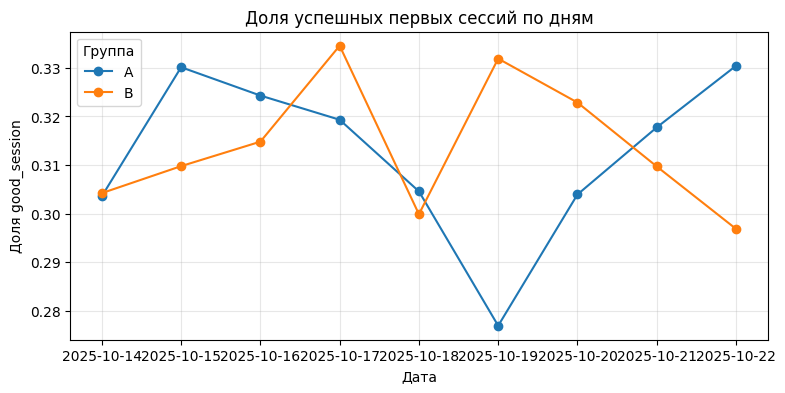

In [7]:
daily = (first.groupby(['session_date', 'test_group'])['good_session']
              .mean().unstack())
daily.plot(marker='o', title='Доля успешных первых сессий по дням')
plt.ylabel('Доля good_session'); plt.xlabel('Дата'); plt.legend(title='Группа'); plt.grid(alpha=.3)
plt.show()

Линии A и B идут рядом без устойчивого расхождения — визуально прироста в группе B не видно.

## 5. Проверка значимости: Z-тест пропорций

- H₀: доля успешных первых сессий одинакова в A и B.
- H₁: в группе B (новый алгоритм) доля **выше** → `alternative='larger'`.

Сначала проверяем предпосылку достаточности данных `n·p ≥ 5` и `n·(1-p) ≥ 5`.

In [8]:
s_a, n_a = conv.loc['A', 'sum'], conv.loc['A', 'count']
s_b, n_b = conv.loc['B', 'sum'], conv.loc['B', 'count']
p_a, p_b = s_a / n_a, s_b / n_b
ok = all(x >= 5 for x in [n_a*p_a, n_a*(1-p_a), n_b*p_b, n_b*(1-p_b)])
print('Предпосылка достаточности данных выполняется!' if ok else 'Предпосылка НЕ выполняется!')

alpha = 0.05
stat, pval = proportions_ztest([s_b, s_a], [n_b, n_a], alternative='larger')
print(f'Z = {stat:.4f}, p-value = {pval:.4f}')
print('Отвергаем H0: прирост значим' if pval < alpha else 'Не удалось отвергнуть H0: прироста нет')

Предпосылка достаточности данных выполняется!
Z = 0.2366, p-value = 0.4065
Не удалось отвергнуть H0: прироста нет


**Вывод.** p-value заметно больше 0.05 → **не отвергаем H₀**. Статистически значимого
прироста доли успешных первых сессий у нового алгоритма нет. (На реальных данных проекта
p ≈ 0.58 — тот же вывод.)

## 6. Дополнительные техники сравнения групп

Дополнительно разбираю ещё два теста — показываю их на тех же данных.

### 6.1 t-тест Стьюдента — среднее число страниц за сессию
Сравнение средних двух независимых выборок. H₁: в B страниц больше (`alternative='greater'`).

In [9]:
m_a = sessions_test[sessions_test.test_group == 'A']['page_counter']
m_b = sessions_test[sessions_test.test_group == 'B']['page_counter']
stat, pval = ttest_ind(m_a, m_b, alternative='greater')
print(f'Среднее страниц: A = {m_a.mean():.3f}, B = {m_b.mean():.3f}')
print(f'p-value = {pval:.4f} -> ' + ('различие значимо' if pval < 0.05 else 'различий нет'))

Среднее страниц: A = 3.311, B = 3.313


p-value = 0.5832 -> различий нет


### 6.2 Тест Манна-Уитни — непараметрическое сравнение распределений
Не требует нормальности, работает на рангах. Двусторонний, α = 0.10.

In [10]:
stat, pval = mannwhitneyu(m_a, m_b, alternative='two-sided')
print(f'p-value = {pval:.4f} -> ' + ('распределения различаются' if pval < 0.10 else 'распределения не различаются'))

p-value = 0.8298 -> распределения не различаются


## Итоги

- **Дизайн.** При α = 0.05, мощности 0.8 и относительном MDE 3 % нужно ≈ 41 тыс.
  пользователей на группу и ≈ 9 дней теста. Ключевой момент — MDE берётся **относительно**
  базовой конверсии, а не в процентных пунктах.
- **Сплит** корректен: группы сопоставимы, пересечений нет.
- **Значимость.** Z-тест пропорций не выявил прироста доли успешных первых сессий
  (p > 0.05). t-тест и тест Манна-Уитни подтверждают отсутствие различий.
- **Бизнес-решение.** Новый алгоритм рекомендаций **не даёт статистически значимого
  улучшения** целевой метрики → внедрять не рекомендуется; при желании — перезапустить
  тест с большей выборкой/длительностью или пересмотреть само изменение.

**Разобранные инструменты:** расчёт размера выборки и MDE (`statsmodels.power`),
проверка сплита, Z-тест пропорций, t-тест Стьюдента, тест Манна-Уитни.
